In [1]:
import os
import sys
import glob
import numpy as np
import  scipy.optimize as op
import matplotlib.pyplot as plt
import urllib.request
from astropy.io import fits as fits
from astropy.table import Table
import pandas as pd
import urllib.request
import requests
import astropy.units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from numpy import savetxt
from PyAstronomy import pyasl
from scipy.interpolate import interp1d
#from dustmaps.sfd import SFDQuery
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt

import os
from astropy.table import Table
from astropy.cosmology import FlatwCDM
import emcee
import numpy as np
import corner
import scipy.optimize as op
import pandas as pd
from astropy.io import ascii
import urllib.request
import requests

#!pip install ipyaladin

from astropy.coordinates import Angle, SkyCoord
from ipyaladin import Aladin, Marker
from pathlib import Path

from astroquery.sdss import SDSS
from astropy import coordinates as coords

from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
import matplotlib.pyplot as plt
import numpy as np

from ipyaladin import Aladin

import time


In [2]:
O_list = pd.read_csv('NewDavidGEHRList.csv',index_col=False)

Hosts = np.unique(O_list['GALAXY'])

#time.sleep(2.4)
len(Hosts)


21

In [3]:
Hosts

array(['MESSIER066', 'MESSIER096', 'MESSIER106', 'NGC1073', 'NGC2500',
       'NGC2541', 'NGC3184', 'NGC3198', 'NGC3319', 'NGC3370', 'NGC4214',
       'NGC4414', 'NGC4496A', 'NGC4496B', 'NGC4535', 'NGC4536', 'NGC4725',
       'NGC5204', 'NGC5584', 'UGC08091', 'UGC09128'], dtype=object)

In [ ]:
counter = 20

aladin = Aladin(
    #target=SkyCoord(coord.ra.degree, coord.dec.degree, unit="deg"),
    target = f"{Hosts[counter]}",
    #target = f"NGC4395",
    fov=Angle(0.08, "deg"),
    height =1000,
    width = 500,
    reticle_size=20,
    coo_frame = "ICRSd",
    reticle_color="#08fd00",
    #overlay_survey = "SDSS9",
    #overlay_survey_opacity = 1,
    survey = "SDSS9"
)

aladin

Aladin(coo_frame='ICRSd', survey='SDSS9')

WidgetReducedError: Jupyter reduces the size of the widget when it is out of the view. This leads to wrong WCS. Either scroll up to the widget, and query the WCS from there, or use the right click menu 'Create New View for Cell Output' to keep the widget in the screen.

In [88]:
fits_o = aladin.get_view_as_fits()

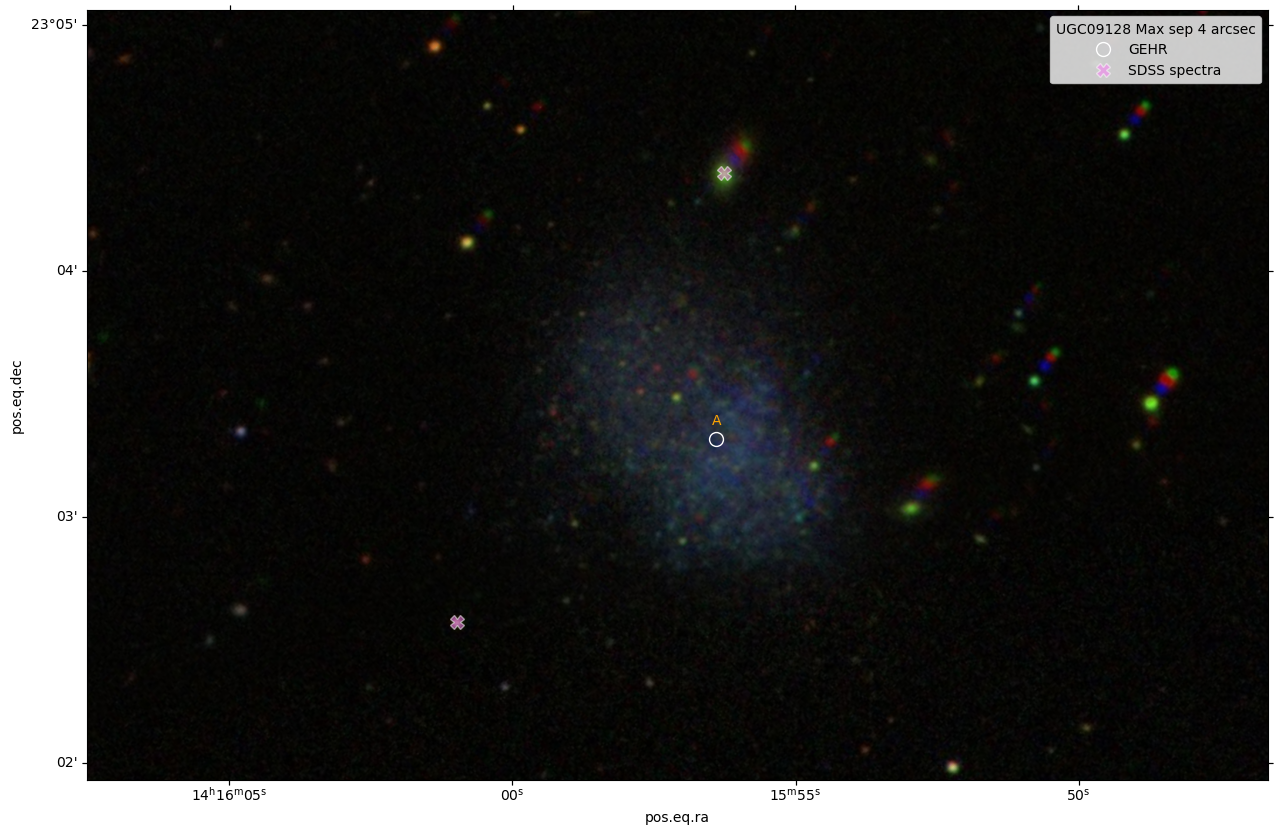

In [89]:
wcs_d = WCS(fits_o[0].header)
r_data = fits_o[0].data[0, :,:]
g_data = fits_o[0].data[1, :,:]
b_data = fits_o[0].data[2, :,:]
rgb_composite = np.dstack((r_data, g_data, b_data))
Gal_sel = O_list[O_list['GALAXY'] == f'{Hosts[counter]}']
f_px,f_py,RA_vG,DEC_vG = [],[],[],[]
for i in range(len(Gal_sel)):
    Point = f"{Gal_sel['RA'].iloc()[i] + ' ' + Gal_sel['DEC'].iloc()[i]}" 
    coord = SkyCoord(Point, unit=(u.hourangle, u.deg), frame='icrs')
    RA_vG.append(coord.ra)
    DEC_vG.append(coord.dec)
    x, y = coord.to_pixel(wcs_d, origin=0)
    f_px.append(x)
    f_py.append(y)
ancho_px = fits_o[0].header['NAXIS1']
alto_px = fits_o[0].header['NAXIS2']
escala_x = abs(fits_o[0].header['CDELT1']) 
escala_y = abs(fits_o[0].header['CDELT2'])
ancho_arcsec = ancho_px * escala_x * 3600
alto_arcsec = alto_px * escala_y * 3600
centro_x = (fits_o[0].header['NAXIS1'] - 1) / 2.0
centro_y = (fits_o[0].header['NAXIS2'] - 1) / 2.0
ra_cent, dec_cent, wave_cent = wcs_d.all_pix2world(centro_x, centro_y, 0,0)
center_im = SkyCoord(ra_cent,dec_cent, unit = (u.deg,u.deg),frame = 'icrs')
xid_spec = SDSS.query_region(center_im, height = f'{alto_arcsec} arcsec', width = f'{ancho_arcsec} arcsec', spectro=True)
s_x,s_y,RA_vS,DEC_vS = [],[],[],[]
for i in range(len(xid_spec)):
    coord_p = SkyCoord(xid_spec['ra'][i],xid_spec['dec'][i], unit=(u.deg, u.deg), frame='icrs')
    RA_vS.append(coord_p.ra)
    DEC_vS.append(coord_p.dec)
    x, y = coord_p.to_pixel(wcs_d, origin=0)
    s_x.append(x)
    s_y.append(y)
fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(1, 1, 1, projection=wcs_d, slices=('x', 'y', 3))
ax.imshow(rgb_composite)
ax.plot(f_px, f_py, fillstyle='none',
        color='white', marker='o', markersize=10, linewidth = 0,
        label='GEHR')
labels = np.array(Gal_sel['CLASS'])
for i, label in enumerate(labels):
    ax.annotate(label, # The text label
                 (f_px[i], f_py[i]), # The point being annotated (xy)
                 textcoords="offset points", # How to position the text
                 xytext=(0, 10),color = 'orange', # Distance from the point (x, y)
                 ha='center') # Horizontal alignment
ax.plot(s_x, s_y,
        markerfacecolor="#fd7af9c6", marker='X', markersize=10, linewidth = 0, markeredgewidth = 1,markeredgecolor='white',
        label='SDSS spectra',alpha=0.5)
sdss_view = SkyCoord(ra=RA_vS, dec=DEC_vS)
GEHR_view = SkyCoord(ra=RA_vG, dec=DEC_vG)
idx, d2d, d3d = GEHR_view.match_to_catalog_sky(sdss_view)
separation = 4
max_sep = separation * u.arcsec
sep_constraint = d2d < max_sep
c_matches = GEHR_view[sep_constraint]
catalog_matches = sdss_view[idx[sep_constraint]]
ax.legend(title = f'{Hosts[counter]} Max sep {separation} arcsec')
if len(catalog_matches) >= 1:
        data_table_onscreen = []
        col_labels_tab = ['RA','DEC','PLATE', 'MJD','FIBER']
        row_labels_tab = []
        for b in range(len(idx)):
             if d2d[b] < max_sep:
                tmp_row = []
                center_match = SkyCoord(sdss_view[idx[b]].ra,sdss_view[idx[b]].dec, unit = (u.deg,u.deg),frame = 'icrs')
                xid_match = SDSS.query_region(center_match, height = f'3 arcsec', width = f'3 arcsec', spectro=True)
                row_labels_tab.append(Gal_sel['NOMBRE'].iloc[b])
                tmp_row.append(xid_match['ra'][0])
                tmp_row.append(xid_match['dec'][0])
                tmp_row.append(xid_match['plate'][0])
                tmp_row.append(xid_match['mjd'][0])
                tmp_row.append(xid_match['fiberID'][0])
                data_table_onscreen.append(tmp_row)
        print(row_labels_tab)
        print(data_table_onscreen)
        ax.axis('on')
        table = ax.table(cellText=data_table_onscreen,
                        colLabels=col_labels_tab,
                        rowLabels=row_labels_tab,
                        colWidths=[0.17, 0.17,0.06,0.06,0.05],
                        loc='lower right') # 'loc' specifies the table's position
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(0.8, 1.0) # Scale the table size
fig.savefig(f'{counter+1}.{Hosts[counter]}.png')


In [ ]:
Gal_sel = O_list[O_list['GALAXY'] == f'{Hosts[counter]}']

Gal_sel

,Numero,NOMBRE,GALAXY,CLASS,RA,DEC,TIEMPO DE EXPOSICION (Segundos),NUMERO DE EXPOSICIONES
35,36,NGC 4414C,NGC4414,C,12:25:43.00,33:30:49.00,900,3
36,37,NGC 4414B,NGC4414,B,12:25:56,33:30:52.00,900,3
37,38,NGC 4414A,NGC4414,A,12:25:57.00,33:31:36.00,900,3


In [ ]:
#.str.strip()+' '+O_list['DEC'].index[0].str.strip()}
T = f"{O_list['RA'].iloc()[0]+' '+O_list['DEC'].iloc()[0]}"
coord = SkyCoord(T, unit=(u.hourangle, u.deg), frame='icrs')
print(f"RA (deg): {coord.ra.degree}")
print(f"Dec (deg): {coord.dec.degree}")

T

In [ ]:

O_list['ra_h'] =  O_list['RA'].str.strip().str.split(':').str[0].astype(int)
O_list['ra_m'] =  O_list['RA'].str.strip().str.split(':').str[1].astype(int)
O_list['ra_s'] =  O_list['RA'].str.strip().str.split(':').str[2].astype(float)
O_list['dec_d'] =  O_list['DEC'].str.strip().str.split(':').str[0].astype(int)
O_list['dec_m'] =  O_list['DEC'].str.strip().str.split(':').str[1].astype(int)
O_list['dec_s'] =  O_list['DEC'].str.strip().str.split(':').str[2].astype(float)
O_list.head()


#print(f"RA (deg): {coord.ra.degree}")
#print(f"Dec (deg): {coord.dec.degree}")


#print(f"Pixel Coordinates: {x}, {y}")


In [ ]:

pos = coords.SkyCoord('0h8m05.63s +14d50m23.3s', frame='icrs')
xid = SDSS.query_region(pos, height = '243.57 arcsec', width = '360 arcsec', spectro=True)

xid

ra,dec,objid,run,rerun,camcol,field,z,plate,mjd,fiberID,specobjid,run2d
float64,float64,uint64,int64,int64,int64,int64,float64,int64,int64,int64,uint64,int64
2.02344596573482,14.8398237551311,1237652943176138868,1739,301,3,315,0.04559058,751,52251,160,845594848269461504,26
2.01642429865501,14.8109891204103,1237652943176139005,1739,301,3,315,0.1135348,752,52251,302,846759780839090176,26


In [ ]:
# Extraer valores del header
ancho_px = fits_o[0].header['NAXIS1']
alto_px = fits_o[0].header['NAXIS2']

# Obtener escala (usamos valor absoluto por si el CDELT es negativo)
escala_x = abs(fits_o[0].header['CDELT1']) 
escala_y = abs(fits_o[0].header['CDELT2'])

# Calcular dimensiones en arcosegundos
ancho_arcsec = ancho_px * escala_x * 3600
alto_arcsec = alto_px * escala_y * 3600

print(f"Dimensiones: {ancho_arcsec:.2f}\" x {alto_arcsec:.2f}\"")

Dimensiones: 360.00" x 243.57"


In [ ]:
centro_x = (fits_o[0].header['NAXIS1'] - 1) / 2.0
centro_y = (fits_o[0].header['NAXIS2'] - 1) / 2.0

# 3. Transformar de píxel a coordenadas de mundo (RA, Dec)
# El argumento '0' indica que el origen de los píxeles es 0 (estilo Python/C)
ra_cent, dec_cent, wave_cent = wcs_d.all_pix2world(centro_x, centro_y, 0,0)

print(f"Centro RA: {ra_cent:.5f}°, Dec: {dec_cent:.5f}°")

Centro RA: 40.91916°, Dec: 1.37587°


In [ ]:
BEta = SkyCoord(ra_cent,dec_cent, unit = (u.deg,u.deg),frame = 'icrs')

BEta.ra.hms

hms_tuple(h=2.0, m=43.0, s=40.59799200000114)

In [ ]:
fits[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    3 / number of array dimensions                     
NAXIS1  =                 1494                                                  
NAXIS2  =                 1000                                                  
NAXIS3  =                    4                                                  
WCSAXES =                    2 / Number of coordinate axes                      
CRPIX1  =                747.5 / Pixel coordinate of reference point            
CRPIX2  =                500.5 / Pixel coordinate of reference point            
CDELT1  = -6.6934404283793E-05 / [deg] Coordinate increment at reference point  
CDELT2  =  6.6934404283794E-05 / [deg] Coordinate increment at reference point  
CUNIT1  = 'deg'                / Units of coordinate increment and value        
CUNIT2  = 'deg'             

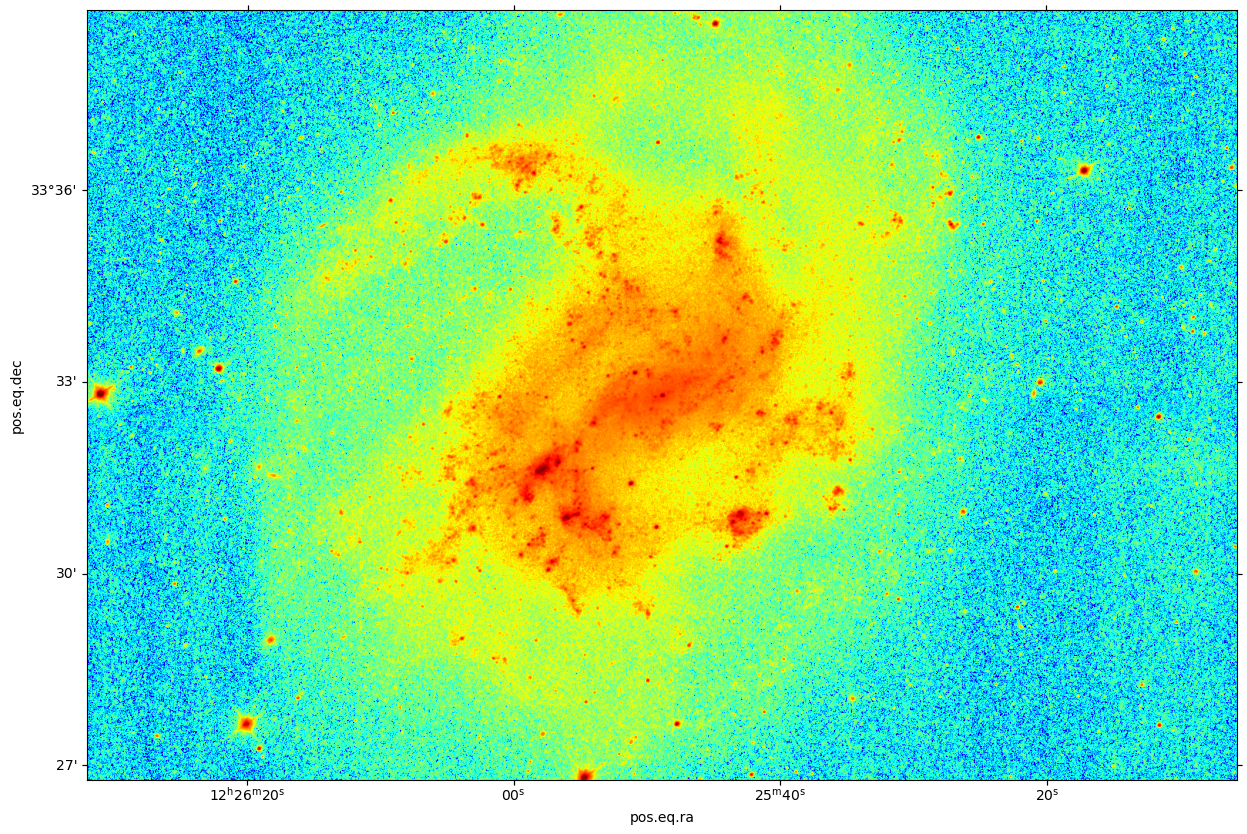

In [ ]:
wcs_d = WCS(fits_o[0].header)



fig = plt.figure(figsize=(20,10))
ax = fig.add_subplot(1, 1, 1, projection=wcs_d, slices=('x', 'y', 3))
ax.imshow(fits_o[0].data[2, :,:], cmap="jet", norm="asinh", vmin=0.001)


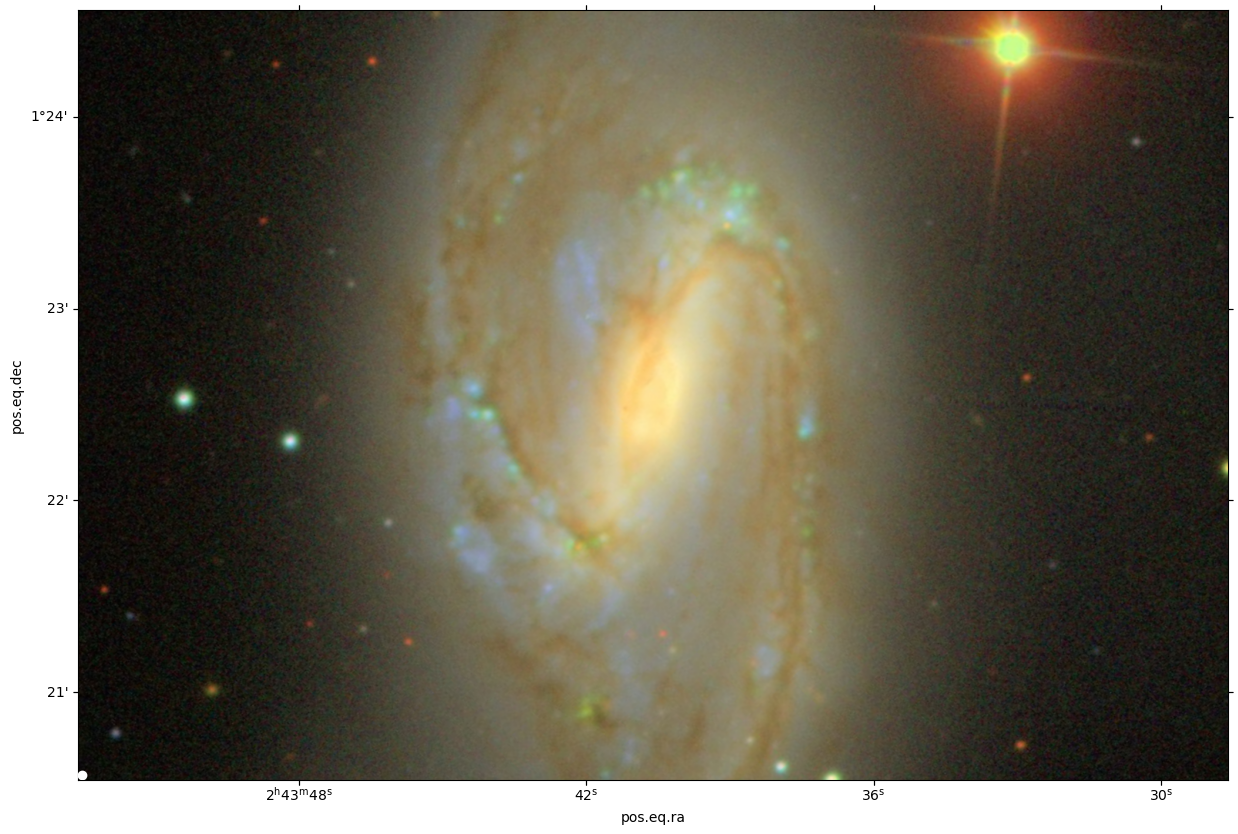

In [ ]:
from astroquery.ipac.ned import Ned

In [ ]:


result_table = Ned.query_object("NGC5584")
result_table[['Object Name', 'RA','DEC','Redshift']]

Object Name,RA,DEC,Redshift
,degrees,degrees,
str30,float64,float64,float64
NGC 5584,215.599,-0.38767,0.005464


In [ ]:
def to_degree(a,b,c,d,e,f):
    a,b,c,d,e,f = int(a),int(b),float(c),int(d),int(e),float(f)
    coord = SkyCoord(f"{a}h{b}m{c}s {d}d{e}m{f}s", unit=(u.hourangle, u.deg), frame='icrs')
    return [coord.ra.degree,coord.dec.degree]

In [ ]:
to_degree(0.0,20,27,59,17,29)

t = coor_c.iloc[0]

t['ra_h']

to_degree(t['ra_h'],t['ra_m'],t['ra_s'],t['dec_d'],t['dec_m'],t['dec_s'])

[5.112499999999999, 59.29138888888889]

In [ ]:
coor_c = pd.read_csv('GEHRFerAr2018coor.csv',index_col=False)


coor_c['ra_deg'] = 0
coor_c['dec_deg'] = 0 

for e in range(len(coor_c)):

    t = coor_c.iloc[e]

    

    coor_c['ra_deg'].iloc[e] =  to_degree(t['ra_h'],t['ra_m'],t['ra_s'],t['dec_d'],t['dec_m'],t['dec_s'])[0]
    coor_c['dec_deg'].iloc[e] =  to_degree(t['ra_h'],t['ra_m'],t['ra_s'],t['dec_d'],t['dec_m'],t['dec_s'])[1]




#coor_c['ra_deg'] = to_degree(coor_c['ra_h'],coor_c['ra_m'],coor_c['ra_s'],coor_c['dec_d'],coor_c['dec_m'],coor_c['dec_s'])[0]

/tmp/ipykernel_7438/2498496770.py:13: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  coor_c['ra_deg'].iloc[e] =  to_degree(t['ra_h'],t['ra_m'],t['ra_s'],t['dec_d'],t['dec_m'],t['dec_s'])[0]
/tmp/ipykernel_7438/2498496770.py:13: SettingWithCop

In [ ]:
#coor_c[['ra_deg','dec_deg']]

In [ ]:
result_table = Ned.query_refcode('1987MNRAS.226..849M')
result_table

No.,Object Name,RA,DEC,Type,Velocity,Redshift,Redshift Flag,Magnitude and Filter,Separation,References,Notes,Photometry Points,Positions,Redshift Points,Diameter Points,Associations
,,degrees,degrees,,km / s,,,,arcmin,,,,,,,
int32,str30,float64,float64,object,float64,float64,object,object,float64,int32,int32,int32,int32,int32,int32,int32
1,NGC 0595,23.39126,30.69124,HII,-174.0,-0.00058,SUN,14.0B,--,107,1,11,7,1,0,0
2,MESSIER 033,23.46204,30.66022,G,-179.0,-0.000598,UUN,6.27,--,2860,22,177,90,28,13,0
3,NGC 0604,23.63796,30.7852,HII,-226.0,-0.000754,SUN,14.0B,--,226,2,29,10,3,0,0
4,Large Magellanic Cloud,80.89417,-69.75611,G,278.0,0.000927,SUN,0.9,--,8440,9,51,33,20,6,0
5,NGC 2366,112.22542,69.21497,G,103.0,0.000344,UUN,11.43,--,643,25,70,53,27,7,1
6,NGC 2403,114.21374,65.60268,G,133.0,0.000445,UUN,8.11B,--,1472,28,218,88,37,8,0
7,Holmberg II,124.77006,70.71992,G,157.0,0.000524,SUN,11.10,--,627,24,123,73,30,7,0
8,IC 2574,157.09728,68.41216,G,57.0,0.00019,SUN,10.80,--,549,16,141,60,21,7,0
